# Phase III: Envelope optimization integrated into surroundings

**Building:** H Building · **Model:** `models/h_envelope_wwr25.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/h_envelope_wwr25_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/h_envelope_wwr25.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 8:06:16.348748


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.000522,0.028591,0.023457,0.007267,0.021793,0.205963,0.200329,0.003009,18.389562,8.544068e+10,1.533301e+11,0,True
1,0.147879,0.135648,0.098804,0.057928,0.141286,0.675222,0.593622,0.007155,24.714675,1.931235e+11,3.124272e+09,0,True
2,0.000439,0.065897,0.002551,0.033731,0.017616,0.200611,0.255705,0.005213,21.932753,8.816906e+10,7.829120e+10,0,True
3,0.146688,0.094198,0.130236,0.148823,0.118401,0.529670,0.712480,0.008716,22.709088,1.437805e+11,3.418183e+09,0,True
4,0.149898,0.113047,0.111202,0.149707,0.120639,0.397908,0.644252,0.008640,23.029354,1.889524e+11,3.340390e+09,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.026603,0.050653,0.078075,0.035493,0.094950,0.265045,0.245860,0.003597,22.637840,1.084798e+11,2.373100e+10,0,False
96,0.132063,0.109237,0.039698,0.117324,0.137739,0.462787,0.510750,0.006145,22.939104,1.432129e+11,4.021112e+09,0,False
97,0.037551,0.091941,0.096124,0.050159,0.057508,0.300475,0.340585,0.007325,22.324908,1.131273e+11,1.866193e+10,0,False
98,0.033065,0.095832,0.092184,0.049185,0.068612,0.270832,0.327956,0.007321,22.376309,1.105198e+11,2.034913e+10,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/876.15)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/876.15)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.000522,0.028591,0.023457,0.007267,0.021793,0.205963,0.200329,0.003009,18.389562,27.088423,48.612316,0,True
1,0.147879,0.135648,0.098804,0.057928,0.141286,0.675222,0.593622,0.007155,24.714675,61.228580,0.990530,0,True
2,0.000439,0.065897,0.002551,0.033731,0.017616,0.200611,0.255705,0.005213,21.932753,27.953440,24.821726,0,True
3,0.146688,0.094198,0.130236,0.148823,0.118401,0.529670,0.712480,0.008716,22.709088,45.584685,1.083713,0,True
4,0.149898,0.113047,0.111202,0.149707,0.120639,0.397908,0.644252,0.008640,23.029354,59.906163,1.059049,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.026603,0.050653,0.078075,0.035493,0.094950,0.265045,0.245860,0.003597,22.637840,34.392838,7.523763,0,False
96,0.132063,0.109237,0.039698,0.117324,0.137739,0.462787,0.510750,0.006145,22.939104,45.404739,1.274868,0,False
97,0.037551,0.091941,0.096124,0.050159,0.057508,0.300475,0.340585,0.007325,22.324908,35.866284,5.916646,0,False
98,0.033065,0.095832,0.092184,0.049185,0.068612,0.270832,0.327956,0.007321,22.376309,35.039607,6.451561,0,False


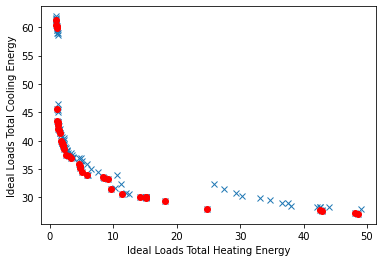

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/h_envelope_wwr25_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

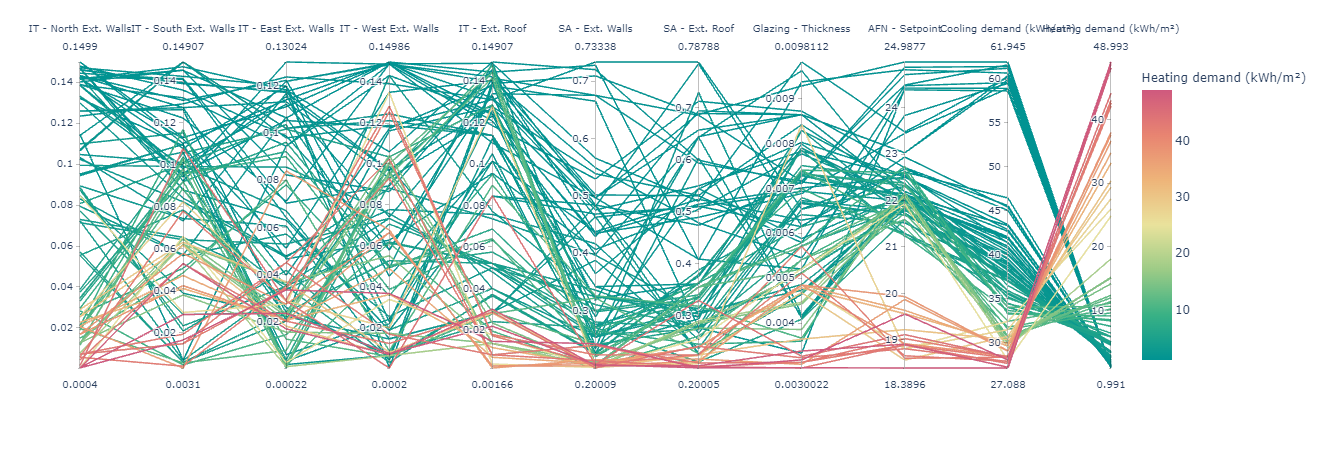

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.000522,0.028591,0.023457,0.007267,0.021793,0.205963,0.200329,0.003009,18.389562,27.088423,48.612316,0,True
1,0.147879,0.135648,0.098804,0.057928,0.141286,0.675222,0.593622,0.007155,24.714675,61.228580,0.990530,0,True
2,0.000439,0.065897,0.002551,0.033731,0.017616,0.200611,0.255705,0.005213,21.932753,27.953440,24.821726,0,True
3,0.146688,0.094198,0.130236,0.148823,0.118401,0.529670,0.712480,0.008716,22.709088,45.584685,1.083713,0,True
4,0.149898,0.113047,0.111202,0.149707,0.120639,0.397908,0.644252,0.008640,23.029354,59.906163,1.059049,0,True
5,0.005645,0.003963,0.034929,0.128258,0.017166,0.206987,0.225284,0.005112,18.653517,27.862123,42.572542,0,True
6,0.007694,0.062077,0.000775,0.006257,0.013499,0.201807,0.290082,0.004464,22.101838,29.410810,18.108895,0,True
7,0.019690,0.005539,0.007671,0.096291,0.028753,0.240970,0.208244,0.005416,21.592961,30.602025,11.424947,0,True
8,0.007173,0.019243,0.045021,0.016706,0.008000,0.212984,0.202422,0.003002,18.882147,27.608521,42.927375,0,True
9,0.000405,0.052999,0.016842,0.006784,0.030015,0.204039,0.204266,0.003380,18.902679,27.174607,48.067999,0,True


In [11]:
results.to_csv('../results/h_envelope_wwr25_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
19,0.077219,0.028591,0.023849,0.007267,0.024013,0.270312,0.211927,0.004088,21.587834,34.483036,5.003766,0,True
